### 0. 환경설정

In [1]:
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Hugging Face의 다운로드 진행바/경고를 줄여 과제 출력이 너무 길어지지 않게 합니다.
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

from transformers import (
    AutoTokenizer,
    AutoModelForMaskedLM,
    AutoModelForCausalLM,
)
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)


c:\Users\harmo\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cpu


### 1. 필수과제

#### 1-1. Scaled Dot-Product Attention 직접구현

In [2]:
# 세 토큰의 Q, K, V 예시
Q = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0],
])

# 첫 번째 Query에서 최대 Attention이 하나만 나오도록 세 번째 Key를 [0.5, 0.5]로 둡니다.
K = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [0.5, 0.5],
])

V = torch.tensor([
    [10.0, 0.0],
    [0.0, 10.0],
    [5.0, 5.0],
])


def scaled_dot_product_attention(Q, K, V, mask=None):
    # [빈칸] d_k는 어떤 벡터의 차원을 뜻하는가?
    # 답: key 벡터의 차원
    d_k = Q.size(-1)

    # TODO 1: Query와 모든 Key의 내적 계산
    scores = Q @ K.T

    # TODO 2: 내적값을 sqrt(d_k)로 나누기
    scaled_scores = scores / math.sqrt(d_k)

    # Mask가 주어진 경우 미래 위치의 score를 -inf로 바꿉니다.
    if mask is not None:
        scaled_scores = scaled_scores.masked_fill(mask, float('-inf'))

    # TODO 3: 마지막 차원에 Softmax를 적용해 Attention Weight 구하기
    weights = torch.softmax(scaled_scores, dim=-1)

    # TODO 4: Attention Weight와 Value의 가중합 계산
    output = weights @ V

    return scores, scaled_scores, weights, output

scores, scaled_scores, weights, output = scaled_dot_product_attention(Q, K, V)

print("[Raw Attention Scores]\n", scores)
print("\n[Scaled Scores]\n", scaled_scores)
print("\n[Attention Weights]\n", weights)
print("\n[Attention Output]\n", output)


[Raw Attention Scores]
 tensor([[1.0000, 0.0000, 0.5000],
        [0.0000, 1.0000, 0.5000],
        [1.0000, 1.0000, 1.0000]])

[Scaled Scores]
 tensor([[0.7071, 0.0000, 0.3536],
        [0.0000, 0.7071, 0.3536],
        [0.7071, 0.7071, 0.7071]])

[Attention Weights]
 tensor([[0.4555, 0.2246, 0.3199],
        [0.2246, 0.4555, 0.3199],
        [0.3333, 0.3333, 0.3333]])

[Attention Output]
 tensor([[6.1546, 3.8454],
        [3.8454, 6.1546],
        [5.0000, 5.0000]])


In [3]:
# 과정 확인 장치: 각 Query의 Attention Weight 합은 1이어야 합니다.
row_sums = weights.sum(dim=-1)
print("각 행의 합:", row_sums)

# TODO 5: row_sums가 모두 1에 가까운지 검증
assert torch.allclose(row_sums, torch.ones_like(row_sums))

# 첫 번째 Query가 가장 크게 참고한 Key의 인덱스
most_attended_key = weights[0].argmax().item()
print("첫 번째 Query가 가장 크게 참고한 Key index:", most_attended_key)


각 행의 합: tensor([1., 1., 1.])
첫 번째 Query가 가장 크게 참고한 Key index: 0


### 1-1 결과 해석

1. 첫 번째 Query가 가장 크게 참고한 Key의 인덱스와 가중치는 얼마인가요?
: 첫 번째 Query가 가장 크게 참고한 Key의 인덱스는 0번(Key1)이고, 가중치는 약 0.4555이다.

2. 그 Key의 가중치가 가장 큰 이유를 Q와 K의 내적 관점에서 설명해주세요.
: 첫 번째 Query Q1=[1,0]과 각 Key를 내적하면 K1=[1,0]과의 내적값이 1로 가장 크다. K2와는 0, K3와는 0.5이므로, K1이 첫 번째 Query와 가장 관련성이 높다고 판단되어 가장 큰 Attention Weight를 갖는다.

3. Attention Output은 Value 하나를 그대로 선택한 결과인가요, 여러 Value를 결합한 결과인가요?
: 여러 Value를 결합한 결과이다. Attention Weight를 가중치로 사용하여 각 Value를 가중합하였다.

4. `sqrt(d_k)`로 나누는 Scaling이 필요한 이유를 Softmax와 연결해 설명해주세요.
: Q와 K의 차원 d_k가 커질수록 내적값도 지나치게 커질 수 있다. 큰 값들이 Softmax에 들어가면 특정 값의 가중치가 1에 가깝고 나머지는 0에 가까워지는 지나치게 극단적인 결과가 나타날 수 있다. 따라서 내적값을 `sqrt(d_k)`로 나누어 크기를 조절함으로써 softmax가 너무 극단적으로 변하는 것을 완화하고 안정적인 attention weight를 얻을 수 있다.


#### 1-2. Look-ahead Mask 적용하기

In [4]:
seq_len = Q.size(0)

# TODO 1: 주대각선 위쪽을 True로 갖는 마스크 만들기
# 힌트: torch.triu(..., diagonal=1)
causal_mask = torch.triu(
    torch.ones(seq_len, seq_len, dtype=torch.bool),
    diagonal=1
)

_, _, unmasked_weights, _ = scaled_dot_product_attention(Q, K, V)
_, _, masked_weights, masked_output = scaled_dot_product_attention(
    Q, K, V, mask=causal_mask
)

print("[Causal Mask]\n", causal_mask)
print("\n[Mask 적용 전 Weight]\n", unmasked_weights)
print("\n[Mask 적용 후 Weight]\n", masked_weights)
print("\n[Masked Attention Output]\n", masked_output)


[Causal Mask]
 tensor([[False,  True,  True],
        [False, False,  True],
        [False, False, False]])

[Mask 적용 전 Weight]
 tensor([[0.4555, 0.2246, 0.3199],
        [0.2246, 0.4555, 0.3199],
        [0.3333, 0.3333, 0.3333]])

[Mask 적용 후 Weight]
 tensor([[1.0000, 0.0000, 0.0000],
        [0.3302, 0.6698, 0.0000],
        [0.3333, 0.3333, 0.3333]])

[Masked Attention Output]
 tensor([[10.0000,  0.0000],
        [ 3.3024,  6.6976],
        [ 5.0000,  5.0000]])


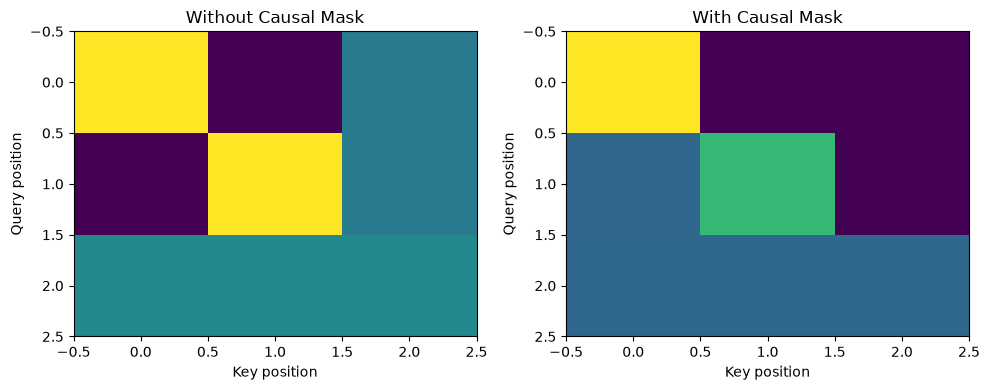

In [5]:
# Attention Weight 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(unmasked_weights.detach().numpy(), aspect="auto")
axes[0].set_title("Without Causal Mask")
axes[0].set_xlabel("Key position")
axes[0].set_ylabel("Query position")

axes[1].imshow(masked_weights.detach().numpy(), aspect="auto")
axes[1].set_title("With Causal Mask")
axes[1].set_xlabel("Key position")
axes[1].set_ylabel("Query position")

plt.tight_layout()
plt.show()

### 1-2 결과 해석

1. Query index 0은 마스크 적용 후 어느 Key까지 참고할 수 있나요?
: Key index 0까지 참고할 수 있ㄷ. 즉, 현재인 자기자신만 참고할 수 있다.

2. 마스크 적용 후 Weight 행렬이 삼각형 모양이 되는 이유를 설명해주세요.
: 각 Query는 자기자신(현재)과 이전시점(과거)의 Key만 참고할 수 있고 미래의 Key는 참고할 수 없기 때문에 삼각형 모양이 된다.

3. Look-ahead Mask를 적용한 위치의 Weight가 0이 되는 과정을 `-∞ → Softmax`와 연결해 서술해주세요.
: Look-ahead Mask가 적용된 미래 위치의 Attention Score를 −∞로 변경한 후 softmax를 적용한다. softmax에서는 e^−∞=0이므로 해당 위치의 attention weight가 0이 되어 미래 토큰을 참고하지 못하게 된다.

4. Padding Mask와 Look-ahead Mask의 목적의 차이를 한 문장씩 간단하게 작성해주세요.
   - **Padding Mask:** 문장의 길이를 맞추기 위해 추가한 Padding 토큰이 Attention 계산에 영향을 주지 않도록 가리는 마스크이다.
   - **Look-ahead Mask:** 현재 토큰이 아직 등장하지 않은 미래 토큰을 참고하지 못하도록 가리는 마스크이다.


#### 1-3. BERT와 GPT의 예측 방식 비교

In [7]:
# 모델 불러오기
bert_name = "bert-base-uncased"
gpt_name = "gpt2"

# TODO 1: BERT tokenizer와 Masked LM model 불러오기
bert_tokenizer = AutoTokenizer.from_pretrained(bert_name)
bert_model = AutoModelForMaskedLM.from_pretrained(bert_name)
_ = bert_model.eval()

# TODO 2: GPT tokenizer와 Causal LM model 불러오기
gpt_tokenizer = AutoTokenizer.from_pretrained(gpt_name)
gpt_model = AutoModelForCausalLM.from_pretrained(gpt_name)
_ = gpt_model.eval()

print("BERT / GPT 모델 로드 완료")


c:\Users\harmo\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\harmo\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\harmo\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_dow

BERT / GPT 모델 로드 완료


In [8]:
# ----- BERT: [MASK]의 앞뒤 문맥을 모두 이용한 단어 예측 -----
# [MASK] 뒤의 "to withdraw money"까지 활용할 수 있다는 점이 핵심
bert_sentence = "I went to the [MASK] to withdraw money."
bert_inputs = bert_tokenizer(bert_sentence, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    bert_logits = bert_model(**bert_inputs).logits

mask_positions = (bert_inputs["input_ids"] == bert_tokenizer.mask_token_id).nonzero(as_tuple=False)
assert len(mask_positions) == 1, "[MASK] 토큰은 정확히 하나만 있어야 합니다."
mask_index = mask_positions[0, 1].item()
mask_logits = bert_logits[0, mask_index, :]

# TODO 3: logit이 높은 상위 5개 토큰의 id 구하기
bert_top_ids = torch.topk(mask_logits, k=5).indices.tolist()
bert_top_tokens = [bert_tokenizer.decode([idx]).strip() for idx in bert_top_ids]
print("문장:", bert_sentence)
print("BERT top-5 predictions:", bert_top_tokens)


문장: I went to the [MASK] to withdraw money.
BERT top-5 predictions: ['bank', 'banks', 'store', 'atm', 'office']


In [10]:
# ----- GPT: 지금까지의 토큰만 이용한 다음 토큰 예측 -----
# GPT는 뒤 문맥을 볼 수 없으므로, 현재까지 주어진 prefix에서 다음 토큰을 예측
gpt_prompt = "I went to the bank to withdraw"
gpt_inputs = gpt_tokenizer(gpt_prompt, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    gpt_logits = gpt_model(**gpt_inputs).logits

next_token_logits = gpt_logits[0, -1, :]

# TODO 4: 다음 토큰 후보 상위 5개의 id 구하기
gpt_top_ids = torch.topk(next_token_logits, k=5).indices.tolist()
gpt_top_tokens = [gpt_tokenizer.decode([idx]) for idx in gpt_top_ids]
print("Prompt:", gpt_prompt)
print("GPT next-token top-5:", gpt_top_tokens)


Prompt: I went to the bank to withdraw
GPT next-token top-5: [' money', ' my', ' the', ' $', ' some']


In [11]:
# GPT의 Autoregressive 생성 과정 관찰
prompt = "In natural language processing, Transformer models can"
inputs = gpt_tokenizer(prompt, return_tensors="pt").to(DEVICE)

# TODO 5: max_new_tokens=20, do_sample=False 조건으로 문장 생성
generated_ids = gpt_model.generate(
    **inputs,
    max_new_tokens=20,
    do_sample=False,
    pad_token_id=gpt_tokenizer.eos_token_id,
)

print(gpt_tokenizer.decode(generated_ids[0], skip_special_tokens=True))


In natural language processing, Transformer models can be used to create a model that is more accurate than the original model.

Transformer models


### 1-3 결과 해석

> **주의:** BERT/GPT의 상위 토큰과 생성 문장은 라이브러리·모델 버전에 따라 조금 달라질 수 있습니다. 반드시 **본인의 실제 출력값을 사용해** 답변을 작성해주시면 됩니다!

1. BERT의 `[MASK]` 상위 5개 예측 중 문맥상 가장 적절하다고 판단한 토큰은 무엇인가요? 그 이유는 무엇인가요?
: bank이다. 돈을 인출하러 [MASK]에 간 것이므로 문맥상 은행이 가장 적절하다.

2. GPT의 다음 토큰 상위 5개 중 자연스럽다고 판단한 후보 2개를 적고, 그 이유도 설명해주세요.
: my, money이다. [무엇]을 인출하러 은행에 방문했다고 했기때문에 my 혹은 money가 자연스럽다고 생각한다.(은행에 남의 것을 인출하러 갔다는 말은 뭔가 이상하다.)

3. BERT와 GPT의 차이를 **Bidirectional / Causal / Masked Self-Attention** 용어를 사용해 설명해주세요.
: BERT는 문장 중간에 단어 하나를 MASK해서 해당 단어의 앞, 뒤 단어, 즉 양방향(Bidirectional)에 있는 단어를 통해 문맥을 추론하여 MASK 된 단어를 예측하는 모델이다.
반면 GPT는 Masked Self-Attention을 사용해서 미래의 토큰을 참고하지 못하도록 Causal MAsk를 적용해서 현재까지 등장한 토큰만을 이용하여 다음 토큰을 순차적으로 예측하는 모델이다.

4. GPT의 생성 결과를 **Autoregressive** 관점에서 서술해주세요.
: GPT는 이전까지 주어진 토큰들을 바탕으로 다음 토큰을 하나씩 예측하고, 새로 생성한 토큰을 다시 입력에 포함하여 다음 토큰을 반복적으로 생성한다. 이러한 방식으로 문장을 순차적으로 완성하는 것을 Autoregressive 생성이라고 한다.


### 2. 심화과제

#### B안. GPT Temperature에 따른 생성 다양성 비교

In [12]:
# B안: temperature에 따른 GPT 생성 다양성 비교
# 여러 방향으로 자연스럽게 이어질 수 있는 prompt를 사용합니다.
prompt = "Once upon a time, a robot discovered"

# TODO 1: 비교할 temperature 값을 입력
temps = [0.3, 0.8, 1.5]

# top_k, 생성 길이 등은 모든 조건에서 동일하게 고정하고
# temperature만 변경하여 그 효과를 비교합니다.
for temp in temps:
    print(f"\n===== temperature={temp} =====")

    # 같은 temperature에서도 3번 생성하여 결과의 다양성을 확인합니다.
    for trial in range(3):
        # 각 temperature에서 같은 trial끼리는 동일한 seed를 사용합니다.
        torch.manual_seed(SEED + trial)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED + trial)

        temp_inputs = gpt_tokenizer(
            prompt,
            return_tensors="pt"
        ).to(DEVICE)

        generated = gpt_model.generate(
            **temp_inputs,
            # TODO 2: 새롭게 생성할 토큰 수를 40으로 설정
            max_new_tokens=40,
            # TODO 3: sampling을 사용하도록 설정
            do_sample=True,
            # TODO 4: 현재 반복문의 temperature를 적용
            temperature=temp,
            # 모든 조건에서 동일하게 유지합니다.
            top_k=50,
            pad_token_id=gpt_tokenizer.eos_token_id,
        )

        text = gpt_tokenizer.decode(
            generated[0],
            skip_special_tokens=True
        )

        print(f"\n[생성 {trial + 1}]")
        print(text)



===== temperature=0.3 =====

[생성 1]
Once upon a time, a robot discovered that it could not be used to pick up the pieces of the puzzle. The robot then began to search for the pieces.

The robot then began to search for the pieces of the puzzle.

[생성 2]
Once upon a time, a robot discovered that it was a human. The robot then began to take over the world, and the humans were able to stop it.

The robot was eventually destroyed by a group of robots. The robot

[생성 3]
Once upon a time, a robot discovered that the world was in danger. It was a robot that had been programmed to be able to survive in a vacuum. The robot was able to survive in a vacuum for a long time and was able

===== temperature=0.8 =====

[생성 1]
Once upon a time, a robot discovered that there was a way to stop the world from ending, and it had a method to do so. The robot's design was so strong that it could drive its own wheels, and it had a

[생성 2]
Once upon a time, a robot discovered that he was on his way to get his 

### 확인할 질문
1. 어느 temperature에서 3개의 생성 결과가 가장 비슷했고, 어느 temperature에서 가장 다양했나요? 실제 생성 문장의 일부를 근거로 설명해세요.
: temperature 0.3에서 3개의 문장의 생성 결과가 가장 비슷했다. 'The robot then began to...'가 반복되었다. temperature 1.5에서 문장의 생성이 가장 다양했다. 'reclanging the wires', 'door wrench' 등 문맥상 어색한 표현이 등장했다.

2. temperature가 높아질수록 문장의 자연스러움과 다양성이 어떻게 변했나요? 예상과 다른 결과가 나왔다면 그 결과도 그대로 편하게 적어주세요.
: temperature가 높아질수록 문장이 부자연스러워지고 다양해졌다. 다양하게 생성되는게 더 좋은 결과일거라고 생각하였는데 부자연스러움이 같이 발생하므로 무조건 temperature를 높인다고 좋지 않다는 것을 알게 되었다.

3. temperature가 Softmax 확률분포에 미치는 영향을 위 실험 결과와 연결해 설명하세요.
: temperature가 낮으면 softmax 확률분포가 뾰족해져 확률이 높은 토큰이 선택될 가능성이 더욱 커지므로, temperature=0.3 에서는 비슷한 표현이 반복되는 경향이 있다. 반대로 temperature가 높으면 확률분포가 평평해져 상대적으로 확률이 낮은 토큰도 선택될 가능성이 증가한다. 이에 따라 temperature=0.8에서는 다양한 내용이 생성되었고, 1.5에서는 다소 어색한 표현까지 등장하여 문장의 자연스러움이 감소하였다.

### B안 결과 해석

- **선택:** B
- **변경한 조건:** 어떤 조건을 고정하고 무엇만 변경했는지 작성하세요.
: 모든 실험에서 동일한 prompt, top_k=50, 생성길이(max_new_tokens=40) 등의 조건은 고정하고, temperature만 0.3, 0.8, 1.5로 변경하여 생성 결과의 다양성과 자연스러움을 비교했다.


# 3. 전체 결과 정리 및 회고

아래 표를 **본인의 실제 실행 결과**를 바탕으로 채워주세요.

| 단계 | 본인이 관찰한 핵심 결과 | 연결되는 개념 |
|---|---|---|
| Attention 직접 구현 | Q와 K의 내적을 계산하고 softmax를 적용한후, 여러 value를 가중합하여 puput을 계산하였다.| Scaled Dot-Product Attention, Q-K-V, Softmax, 가중합  |
| Causal Mask 적용 | 미래 Key에 해당하는 Attention Weight가 0이 되어 각 Query가 자기 자신과 이전 토큰만 참고하는 것을 확인하였다. | Causal Mask, Look-ahead Mask, Masked Self-Attention |
| BERT 실험 | "I went to the [MASK] to withdraw money."에서 bank, banks, store, atm, office 순으로 예측되었으며, 앞뒤 문맥을 모두 활용해 bank를 가장 높은 순위로 예측했다. | transformer, encoder, bidirection, masked language model |
| GPT 실험 | "I went to the bank to withdraw" 다음 토큰으로 money, my, the, $, some 등이 높은 순위로 나타났으며, 이전 토큰만을 이용해 다음 토큰을 예측하였다.| transformer, decoder, causal LM, Autoregressivem, masked self-attention |

1. **가장 어려웠던 단계와 해결 방법**
   - 답: attention에서 Q, K, V의 역할과 Causal Mask가 적용되는 위치를 이해하는 것이 어려웠다. 또한 최종 output 행렬을 계산하는 과정이 이해하기가 조금 어려웠다. 직접 Query, Key 내적부터 시작해서 손으로 계산해보면서 계산과정을 이해하였다.

2. **실행 전 예상과 실제 결과가 가장 달랐던 부분**
   - 답: Temperature가 높아질수록 생성 결과의 다양성이 뚜렷하게 증가할 것이라고 예상했지만, 실제론,temperature=0.8에서 내용적 다양성과 문맥의 자연스러움이 가장 잘 나타났고 1.5에서는 다양성 증가보단 부자연스러운 표현과 문맥의 일관성 저하가 더 나타났다.

3. **기술블로그의 ‘과제 복습’ 섹션에 정리할 핵심 개념**
   - 답: transformer의 핵심인 scaled dot-product attention의 Q, K, V와 Softmax를 통한 Attention Weight 계산 과정, 미래 토큰을 차단하는 Causal Mask와 Masked Self-Attention, 그리고 이를 바탕으로 한 BERT의 양방향 Masked LM과 GPT의 Autoregressive Causal LM의 차이를 중심으로 정리하고자 한다. 또한 Temperature가 softmax 확률분포와 생성결과의 다양성에 미치는 영향도 함께 정리할 수 있다.


# 4. 생성형 AI 활용 방법 및 대화 내역

> **반드시 작성하세요.** 문제를 풀면서 GPT, Claude 등 생성형 AI를 어디에 어떻게 사용했는지 기록합니다.

## 1) 활용한 생성형 AI
- 사용한 도구: GPT
- 사용한 문제/단계: attention 계산과정
- 사용 목적: attention 계산과정 참고 및 검토

## 2) AI 답변을 그대로 사용하지 않고 직접 검증한 방법
- 답: 답변을 읽고 세션자료와 비교한다.

## 3) AI와의 실제 대화 내역
### 대화 내역
value랑 attention weights 가 이미지와 같을때 attention output을어떻게 계산한다는거지?

맞아. 여기서 핵심은 Attention Weight와 Value를 행렬곱해서 각 Query의 최종 Output을 만든다는 거야.

주어진 값부터 써보면,

W=
	​

0.4555
0.2246
0.3333
	​

0.2246
0.4555
0.3333
	​

0.3199
0.3199
0.3333
	​

	​


이고,

V=
	​

10
0
5
	​

0
10
5
	​

	​


이야.

Attention Output은

Output=WV
	​


로 계산해.

첫 번째 Query의 Output을 직접 계산해보자

첫 번째 Query의 Attention Weight는

[0.4555,0.2246,0.3199]

야.

이건 쉽게 말해서

첫 번째 Query가 V₁을 45.55%, V₂를 22.46%, V₃를 31.99% 참고하겠다

는 뜻이야.

Value는 각각

V
1
	​

=[10,0]
V
2
	​

=[0,10]
V
3
	​

=[5,5]

니까 가중합하면

Output
1
	​

=0.4555V
1
	​

+0.2246V
2
	​

+0.3199V
3
	​


각각 계산하면

0.4555[10,0]=[4.555,0]
0.2246[0,10]=[0,2.246]
0.3199[5,5]=[1.5995,1.5995]

전부 더해서

[4.555,0]+[0,2.246]+[1.5995,1.5995]

따라서

Output
1
	​

=[6.1545,3.8455]
	​


가 되는 거야.

두 번째 Query도 똑같아

두 번째 Attention Weight:

[0.2246,0.4555,0.3199]

따라서

Output
2
	​

=0.2246V
1
	​

+0.4555V
2
	​

+0.3199V
3
	​


계산하면

=0.2246[10,0]+0.4555[0,10]+0.3199[5,5]
=[2.246,0]+[0,4.555]+[1.5995,1.5995]

그래서

Output
2
	​

=[3.8455,6.1545]
	​

세 번째 Query

Attention Weight가

[0.3333,0.3333,0.3333]

즉 세 Value를 거의 똑같이 참고해.

Output
3
	​

=0.3333V
1
	​

+0.3333V
2
	​

+0.3333V
3
	​

=0.3333[10,0]+0.3333[0,10]+0.3333[5,5]
=[3.333,0]+[0,3.333]+[1.6665,1.6665]

따라서 대략

Output
3
	​

=[5,5]
	​

최종 Attention Output

따라서 전체 결과는 대략

Output=
	​

6.1545
3.8455
5.0000
	​

3.8455
6.1545
5.0000
	​

	​

	​


가 돼.

코드 한 줄로는 이거였고:

output = weights @ V
그런데 왜 굳이 이렇게 하는 거야?

이 부분을 이해하면 Attention이 거의 이해된 거야.

첫 번째 토큰의 원래 Value가

V
1
	​

=[10,0]

였잖아.

그런데 Attention을 거친 후에는

[10,0]→[6.15,3.85]

정도로 바뀌었어.

왜냐하면 첫 번째 토큰이 자기 정보만 사용하는 게 아니라 다른 토큰들의 정보도 Attention Weight만큼 가져왔기 때문이야.

즉,

Attention 전

토큰 1: 나는 [10,0]이라는 정보만 가지고 있음.

Attention 후

토큰 1: 다른 토큰들을 살펴보니
토큰1 정보 45.55% + 토큰2 정보 22.46% + 토큰3 정보 31.99%를 참고해야겠네.
→ 새로운 표현 [6.15, 3.85]

이 되는 거야.

그래서 Attention Output은 "다른 토큰들과의 관계를 고려해서 새롭게 만들어진 각 토큰의 표현"이라고 이해하면 가장 좋아.
